LIBRARIES

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from scipy.stats import norm

IMPORT DATA

In [59]:
data = pd.read_excel("D:\\program\\my project\\Diet.xlsx")

In [61]:
data.head()

,gender,Diet,weight,weight6weeks
0,M,B,60,60.0
1,M,B,103,103.0
2,F,A,58,54.2
3,F,A,60,54.0
4,F,A,64,63.3


In [63]:
print(data.dtypes)

gender           object
Diet             object
weight            int64
weight6weeks    float64
dtype: object


In [65]:
data["weight_loss"] = data.apply(lambda row: row.weight - row.weight6weeks, axis=1)

In [67]:
data.head()

,gender,Diet,weight,weight6weeks,weight_loss
0,M,B,60,60.0,0.0
1,M,B,103,103.0,0.0
2,F,A,58,54.2,3.8
3,F,A,60,54.0,6.0
4,F,A,64,63.3,0.7


In [69]:
df = data['weight_loss']
print(df)

0     0.0
1     0.0
2     3.8
3     6.0
4     0.7
     ... 
73    2.8
74    4.1
75    5.3
76    9.2
77    6.1
Name: weight_loss, Length: 78, dtype: float64


In [71]:
mean = np.mean(df)

In [73]:
print(mean)

3.8448717948717945


In [75]:
std = np.std(df)

In [77]:
print(std)

2.5350692822119716


In [79]:
x = np.linspace(mean - 4*std, mean + 4*std, 100)

In [81]:
y = norm(loc=mean,scale=std).pdf(x)

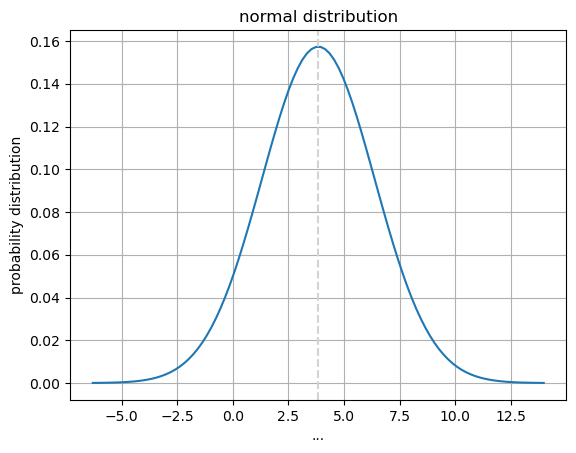

In [83]:
plt.plot(x,y)
plt.grid(True)
plt.axvline(mean, ls="--", color="lightgrey")
plt.title('normal distribution')
plt.xlabel('...')
plt.ylabel('probability distribution')
plt.show()

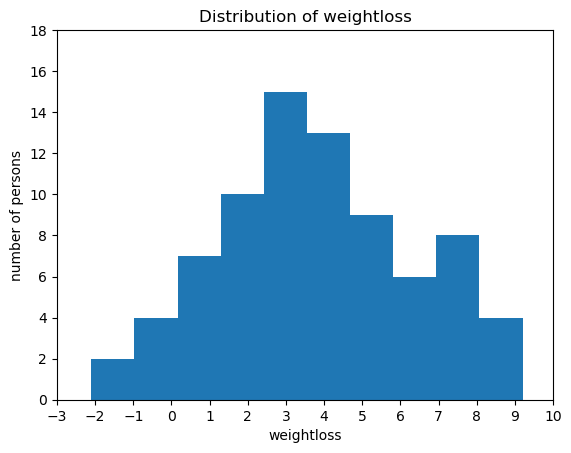

In [84]:
plt.hist(df)
plt.title('Distribution of weightloss')
plt.xlabel('weightloss')
plt.ylabel('number of persons')
plt.xticks([-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10])
plt.yticks([0,2,4,6,8,10,12,14,16,18])
plt.show()

In [86]:
test_result1 = stats.shapiro(df)

In [87]:
print(test_result1)

ShapiroResult(statistic=0.9899081789573966, pvalue=0.8019883459467786)


In [88]:
if test_result1.pvalue > 0.05:
    print("The given dataset follows the normal distribution.")
else:
    print("The given dataset do not follows the normal distribution.")

The given dataset follows the normal distribution.


In [97]:
two_way_anova_test = ols('weight_loss~(gender)+(Diet)+(gender):(Diet)', data=data).fit()

In [210]:
results = sm.stats.anova_lm(two_way_anova_test, typ=2)

In [212]:
print(results)

                 sum_sq    df         F    PR(>F)
gender         0.135526   1.0  0.024099  0.877067
Diet          71.007031   2.0  6.313248  0.002977
gender:Diet   25.140704   2.0  2.235264  0.114336
Residual     404.903029  72.0       NaN       NaN


In [103]:
alpha = 0.05

In [105]:
if results['PR(>F)']['gender'] < alpha or results['PR(>F)']['Diet'] < alpha or results['PR(>F)']['gender:Diet'] < alpha:
    print("Reject the hypothesis, as there is a significant difference")
else:
    print("Accept the hypothesis, as there is a significant difference.")

Reject the hypothesis, as there is a significant difference


In [107]:
m_data = data[data['gender'] == 'M']

In [109]:
print(m_data)

   gender Diet  weight  weight6weeks  weight_loss
0       M    B      60          60.0          0.0
1       M    B     103         103.0          0.0
45      M    A      71          71.6         -0.6
46      M    A      72          70.9          1.1
47      M    A      74          69.5          4.5
48      M    A      78          73.9          4.1
49      M    A      80          71.0          9.0
50      M    A      80          77.6          2.4
51      M    A      83          79.1          3.9
52      M    A      85          81.5          3.5
53      M    A      87          81.9          5.1
54      M    A      88          84.5          3.5
55      M    B      71          66.8          4.2
56      M    B      75          72.6          2.4
57      M    B      75          69.2          5.8
58      M    B      76          72.5          3.5
59      M    B      78          72.7          5.3
60      M    B      78          76.3          1.7
61      M    B      79          73.6          5.4


In [111]:
f_data = data[data['gender'] == 'F']

In [113]:
print(f_data)

   gender Diet  weight  weight6weeks  weight_loss
2       F    A      58          54.2          3.8
3       F    A      60          54.0          6.0
4       F    A      64          63.3          0.7
5       F    A      64          61.1          2.9
6       F    A      65          62.2          2.8
7       F    A      66          64.0          2.0
8       F    A      67          65.0          2.0
9       F    A      69          60.5          8.5
10      F    A      70          68.1          1.9
11      F    A      70          66.9          3.1
12      F    A      72          70.5          1.5
13      F    A      72          69.0          3.0
14      F    A      72          68.4          3.6
15      F    A      82          81.1          0.9
16      F    B      58          60.1         -2.1
17      F    B      58          56.0          2.0
18      F    B      59          57.3          1.7
19      F    B      61          56.7          4.3
20      F    B      62          55.0          7.0


In [115]:
m_A_data = m_data[m_data['Diet'] == 'A']

In [117]:
print(m_A_data)

   gender Diet  weight  weight6weeks  weight_loss
45      M    A      71          71.6         -0.6
46      M    A      72          70.9          1.1
47      M    A      74          69.5          4.5
48      M    A      78          73.9          4.1
49      M    A      80          71.0          9.0
50      M    A      80          77.6          2.4
51      M    A      83          79.1          3.9
52      M    A      85          81.5          3.5
53      M    A      87          81.9          5.1
54      M    A      88          84.5          3.5


In [119]:
m_B_data = m_data[m_data['Diet'] == 'B']

In [121]:
print(m_B_data)

   gender Diet  weight  weight6weeks  weight_loss
0       M    B      60          60.0          0.0
1       M    B     103         103.0          0.0
55      M    B      71          66.8          4.2
56      M    B      75          72.6          2.4
57      M    B      75          69.2          5.8
58      M    B      76          72.5          3.5
59      M    B      78          72.7          5.3
60      M    B      78          76.3          1.7
61      M    B      79          73.6          5.4
62      M    B      79          72.9          6.1
63      M    B      79          71.1          7.9
64      M    B      80          81.4         -1.4
65      M    B      80          75.7          4.3


In [123]:
m_C_data = m_data[m_data['Diet'] == 'C']

In [125]:
print(m_C_data)

   gender Diet  weight  weight6weeks  weight_loss
66      M    C      71          68.5          2.5
67      M    C      73          72.1          0.9
68      M    C      76          72.5          3.5
69      M    C      78          77.5          0.5
70      M    C      78          75.2          2.8
71      M    C      78          69.4          8.6
72      M    C      79          74.5          4.5
73      M    C      83          80.2          2.8
74      M    C      84          79.9          4.1
75      M    C      85          79.7          5.3
76      M    C      87          77.8          9.2
77      M    C      88          81.9          6.1


In [127]:
f_A_data = f_data[f_data['Diet'] == 'A']

In [129]:
print(f_A_data)

   gender Diet  weight  weight6weeks  weight_loss
2       F    A      58          54.2          3.8
3       F    A      60          54.0          6.0
4       F    A      64          63.3          0.7
5       F    A      64          61.1          2.9
6       F    A      65          62.2          2.8
7       F    A      66          64.0          2.0
8       F    A      67          65.0          2.0
9       F    A      69          60.5          8.5
10      F    A      70          68.1          1.9
11      F    A      70          66.9          3.1
12      F    A      72          70.5          1.5
13      F    A      72          69.0          3.0
14      F    A      72          68.4          3.6
15      F    A      82          81.1          0.9


In [131]:
f_B_data = f_data[f_data['Diet'] == 'B']

In [133]:
print(f_B_data)

   gender Diet  weight  weight6weeks  weight_loss
16      F    B      58          60.1         -2.1
17      F    B      58          56.0          2.0
18      F    B      59          57.3          1.7
19      F    B      61          56.7          4.3
20      F    B      62          55.0          7.0
21      F    B      63          62.4          0.6
22      F    B      63          60.3          2.7
23      F    B      63          59.4          3.6
24      F    B      65          62.0          3.0
25      F    B      66          64.0          2.0
26      F    B      68          63.8          4.2
27      F    B      68          63.3          4.7
28      F    B      76          72.7          3.3
29      F    B      77          77.5         -0.5


In [135]:
f_C_data = f_data[f_data['Diet'] == 'C']

In [137]:
print(f_C_data)

   gender Diet  weight  weight6weeks  weight_loss
30      F    C      60          53.0          7.0
31      F    C      62          56.4          5.6
32      F    C      64          60.6          3.4
33      F    C      65          58.2          6.8
34      F    C      66          58.2          7.8
35      F    C      67          61.6          5.4
36      F    C      67          60.2          6.8
37      F    C      69          61.8          7.2
38      F    C      70          63.0          7.0
39      F    C      70          62.7          7.3
40      F    C      72          71.1          0.9
41      F    C      72          64.4          7.6
42      F    C      73          68.9          4.1
43      F    C      75          68.7          6.3
44      F    C      76          71.0          5.0


In [139]:
count_m = m_data['weight'].count().sum()

In [141]:
count_m

35

In [143]:
count_f = f_data['weight'].count().sum()

In [145]:
count_f

43

In [147]:
count_f_A = f_A_data['weight'].count().sum()

In [149]:
count_f_A

14

In [151]:
count_f_B = f_B_data['weight'].count().sum()

In [153]:
print(count_f_B)

14


In [155]:
count_f_C = f_C_data['weight'].count().sum()

In [157]:
print(count_f_C)

15


In [159]:
count_m_A = m_A_data['weight'].count().sum()

In [161]:
print(count_m_A)

10


In [163]:
count_m_B = m_B_data['weight'].count().sum()

In [165]:
print(count_m_B)

13


In [167]:
count_m_C = m_C_data['weight'].count().sum()

In [169]:
print(count_m_C)

12


In [171]:
count_data = ([count_f_A,count_f_B,count_f_C,count_m_A,count_m_B,count_m_C])

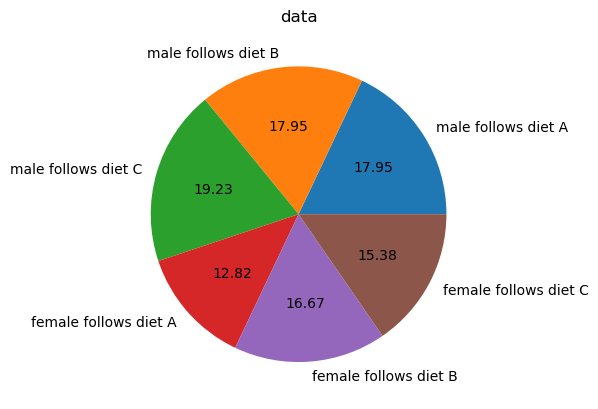

In [173]:
labels = (['male follows diet A', 'male follows diet B', 'male follows diet C',
           'female follows diet A', 'female follows diet B', 'female follows diet C'])
plt.pie(count_data, labels = labels, autopct = '%.2f')
plt.title('data')


plt.show()


In [175]:
mean1 = np.mean(m_A_data['weight_loss'])
mean2 = np.mean(m_B_data['weight_loss'])
mean3 = np.mean(m_C_data['weight_loss'])
mean4 = np.mean(f_A_data['weight_loss'])
mean5 = np.mean(f_B_data['weight_loss'])
mean6 = np.mean(f_C_data['weight_loss'])

In [177]:
mean = ([mean1, mean2, mean3, mean4, mean5, mean6])

In [179]:
min1 = np.min(m_A_data['weight_loss'])
min2 = np.min(m_B_data['weight_loss'])
min3 = np.min(m_C_data['weight_loss'])
min4 = np.min(f_A_data['weight_loss'])
min5 = np.min(f_B_data['weight_loss'])
min6 = np.min(f_C_data['weight_loss'])

In [181]:
min = ([min1, min2, min3, min4, min5, min6])

In [183]:
max1 = np.max(m_A_data['weight_loss'])
max2 = np.max(m_B_data['weight_loss'])
max3 = np.max(m_C_data['weight_loss'])
max4 = np.max(f_A_data['weight_loss'])
max5 = np.max(f_B_data['weight_loss'])
max6 = np.max(f_C_data['weight_loss'])

In [185]:
max = ([max1, max2, max3, max4, max5, max6])

In [187]:
var1 = np.var(m_A_data['weight_loss'])
var2 = np.var(m_B_data['weight_loss'])
var3 = np.var(m_C_data['weight_loss'])
var4 = np.var(f_A_data['weight_loss'])
var5 = np.var(f_B_data['weight_loss'])
var6 = np.var(f_C_data['weight_loss'])

In [189]:
variance = ([var1,var2,var3,var4,var5,var6])

In [191]:
summary = pd.DataFrame({
    'Name': labels,
    'Mean': mean, 
    'Minimum': min,
    'Maximum': max,
    'total no of datapoints':count_data,
    'Variance': variance
})



In [200]:
summary

,Name,Mean,Minimum,Maximum,total no of datapoints,Variance
0,male follows diet A,3.650000,-0.6,9.0,14,5.788500
1,male follows diet B,3.476923,-1.4,7.9,14,7.103314
2,male follows diet C,4.233333,0.5,9.2,15,6.762222
3,female follows diet A,3.050000,0.7,8.5,10,3.959643
4,female follows diet B,2.607143,-2.1,7.0,13,4.864949
5,female follows diet C,5.880000,0.9,7.8,12,3.332267
